<a href="https://colab.research.google.com/github/AliAnusKhan/neuro-five-telco-customer-churn-prediction/blob/main/Telec0_Customer_churn_neurofive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [125]:
from google.colab import drive
drive.mount( '/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [126]:
import pandas as pd
file_path='/content/drive/MyDrive/dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'
nfive=pd.read_csv(file_path)
nfive.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [127]:
print("Rows & Coulmns:")
nfive.shape

Rows & Coulmns:


(7043, 21)

In [128]:
print("Data Information:")
nfive.info()

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [129]:
print("Statistical Data:")
nfive.describe()

Statistical Data:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [130]:
print("Missing Values:")
nfive.isnull().sum()

Missing Values:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [131]:
print("Duplicates:")
duplicate_rows = nfive.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)
duplicate_columns = nfive.columns.duplicated().sum()
print("Number of duplicate columns:", duplicate_columns)

Duplicates:
Number of duplicate rows: 0
Number of duplicate columns: 0


In [132]:
nfive.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [133]:
print("Numerical Vs Categorical:")
numerical_col=nfive.select_dtypes(include=['number']).columns
categorical_col=nfive.select_dtypes(include=['object']).columns
print("Numerical Columns:",numerical_col)
print("Categorical Columns:",categorical_col)
print("Numerical Columns:",len(numerical_col))
print("Categorical Columns:",len(categorical_col))

Numerical Vs Categorical:
Numerical Columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')
Categorical Columns: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')
Numerical Columns: 3
Categorical Columns: 18


In [134]:
print("Target variable analysis:")
nfive['Churn'].value_counts()
nfive['Churn'].value_counts(normalize=True)*100

Target variable analysis:


,proportion
Churn,
No,73.463013
Yes,26.536987


<Axes: xlabel='Churn'>

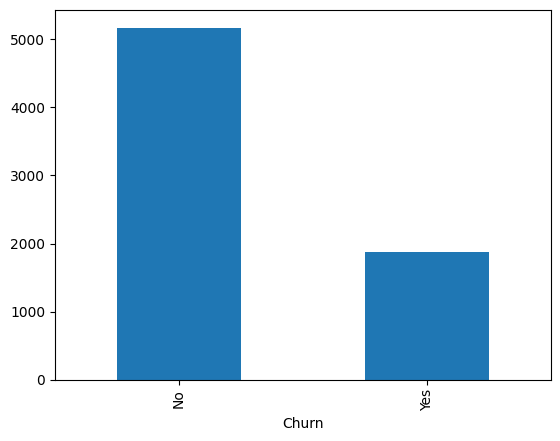

In [135]:
nfive['Churn'].value_counts().plot(kind='bar')

Dataset is moderately imbalanced because customers who did not churn are significantly more than customers who churned.

In [136]:

nfive['TotalCharges'] = pd.to_numeric(nfive['TotalCharges'], errors='coerce')
nfive['TotalCharges'] = nfive['TotalCharges'].fillna(0)
nfive[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


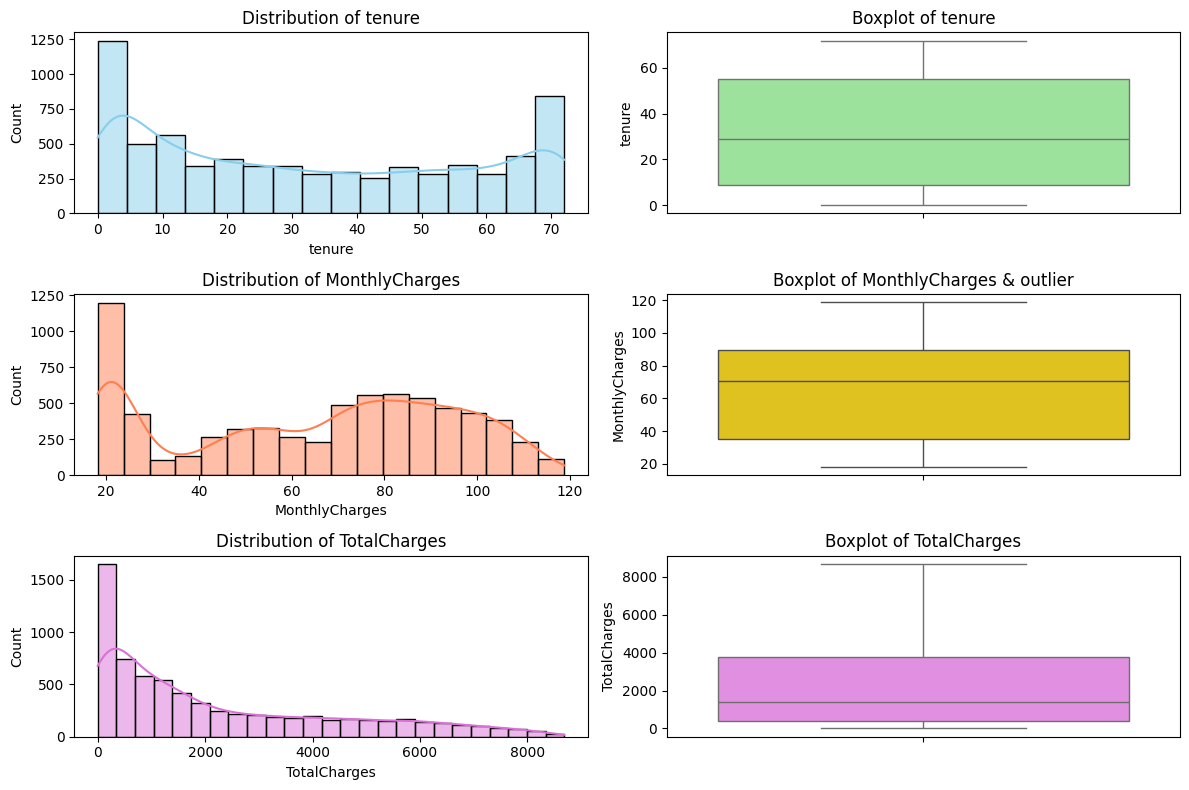

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes=plt.subplots(3,2,figsize=(12,8))

sns.histplot(nfive['tenure'],kde=True,ax=axes[0,0],color='skyblue')
axes[0,0].set_title('Distribution of tenure')
axes[0,0].set_label('tenure(months)')

sns.boxplot(nfive['tenure'],ax=axes[0,1],color='lightgreen')
axes[0,1].set_title('Boxplot of tenure')
axes[0,1].set_label('tenure(months)')

sns.histplot(nfive['MonthlyCharges'],kde='True',ax=axes[1,0],color='coral')
axes[1,0].set_title('Distribution of MonthlyCharges')
axes[1,0].set_label('MonthlyCharges')

sns.boxplot(nfive['MonthlyCharges'],ax=axes[1,1],color='gold')
axes[1,1].set_title('Boxplot of MonthlyCharges & outlier')
axes[1,1].set_label('MonthlyCharges')

sns.histplot(nfive['TotalCharges'],kde=True,ax=axes[2,0],color='orchid')
axes[2,0].set_title('Distribution of TotalCharges')
axes[2,0].set_label('TotalCharges')

sns.boxplot(nfive['TotalCharges'],ax=axes[2,1],color='violet')
axes[2,1].set_title('Boxplot of TotalCharges')
axes[2,1].set_label('TotalCharges')

plt.tight_layout()
plt.show()


All three numerical features (tenure, MonthlyCharges, and TotalCharges) show no extreme outliers. Both tenure and MonthlyCharges exhibit bimodal distributions representing distinct customer segments, whereas TotalCharges is right-skewed with most values concentrated at lower amounts.

Categorical Columns feature


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


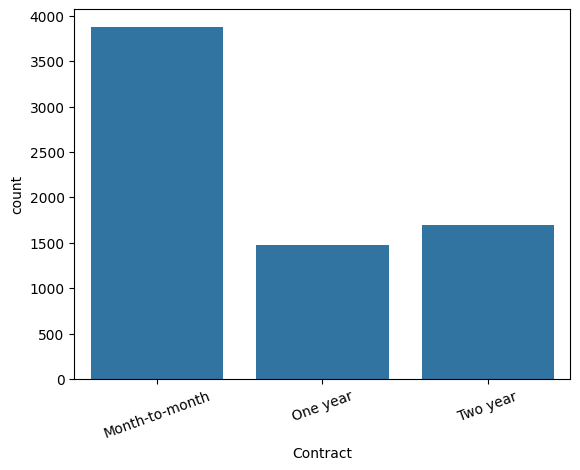

In [138]:
print(nfive['Contract'].value_counts())
print(nfive['Contract'].value_counts(normalize=True)*100)
sns.countplot(x='Contract',data=nfive)
plt.xticks(rotation=20)
plt.show()


In [139]:
nfive['Partner'].value_counts()
nfive['Partner'].value_counts(normalize=True)*100

,proportion
Partner,
No,51.69672
Yes,48.30328


In [140]:
nfive['InternetService'].value_counts()
nfive['InternetService'].value_counts(normalize=True)*100

,proportion
InternetService,
Fiber optic,43.958540
DSL,34.374556
No,21.666903


In [141]:
nfive['PaymentMethod'].value_counts()
nfive['PaymentMethod'].value_counts(normalize=True)*100

,proportion
PaymentMethod,
Electronic check,33.579441
Mailed check,22.887974
Bank transfer (automatic),21.922476
Credit card (automatic),21.610109


In [142]:
nfive['PaperlessBilling'].value_counts()
nfive['PaperlessBilling'].value_counts(normalize=True)*100


,proportion
PaperlessBilling,
Yes,59.221922
No,40.778078


In [143]:
nfive['SeniorCitizen'].value_counts()
nfive['SeniorCitizen'].value_counts(normalize=True)*100

,proportion
SeniorCitizen,
0,83.785319
1,16.214681


Bivariate Analysis


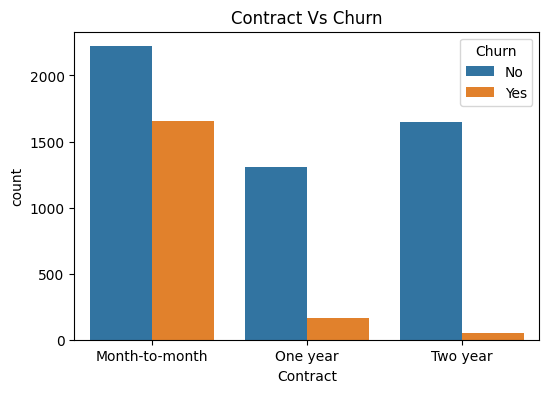

In [144]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract',hue='Churn',data=nfive)
plt.title('Contract Vs Churn')
plt.show()

In [145]:
pd.crosstab(nfive['Contract'],nfive['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


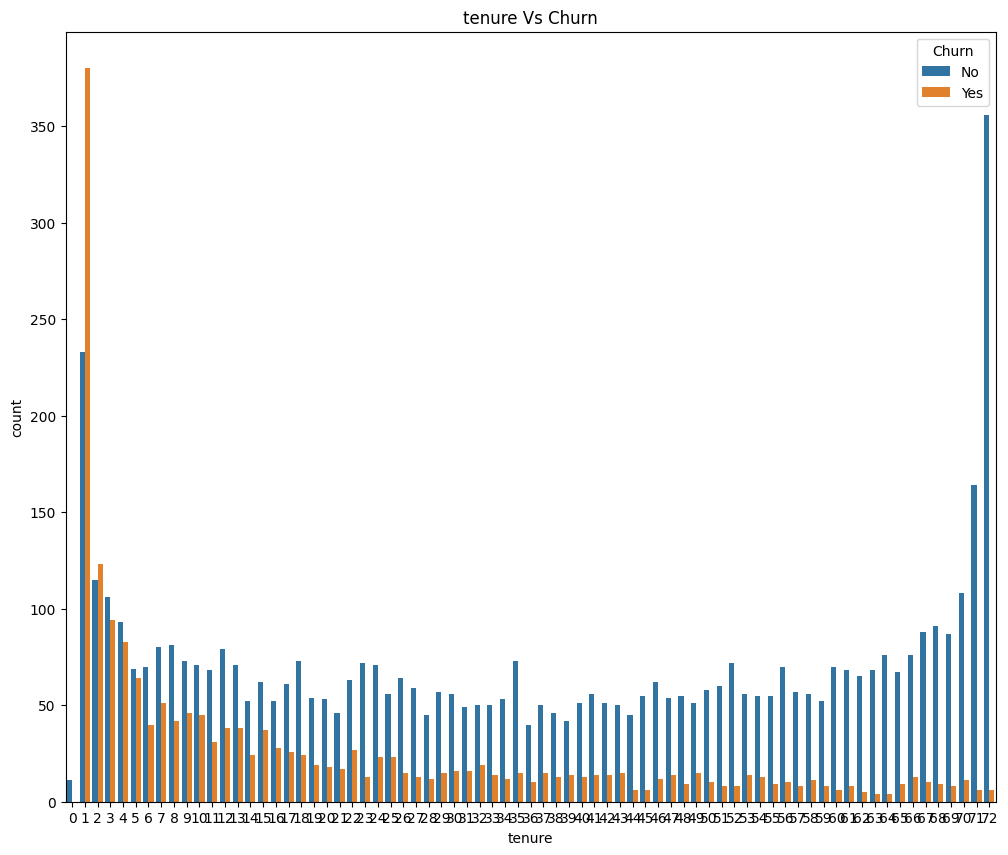

In [146]:
plt.figure(figsize=(12,10))
sns.countplot(x='tenure',hue='Churn',data=nfive)
plt.title('tenure Vs Churn')
plt.show()


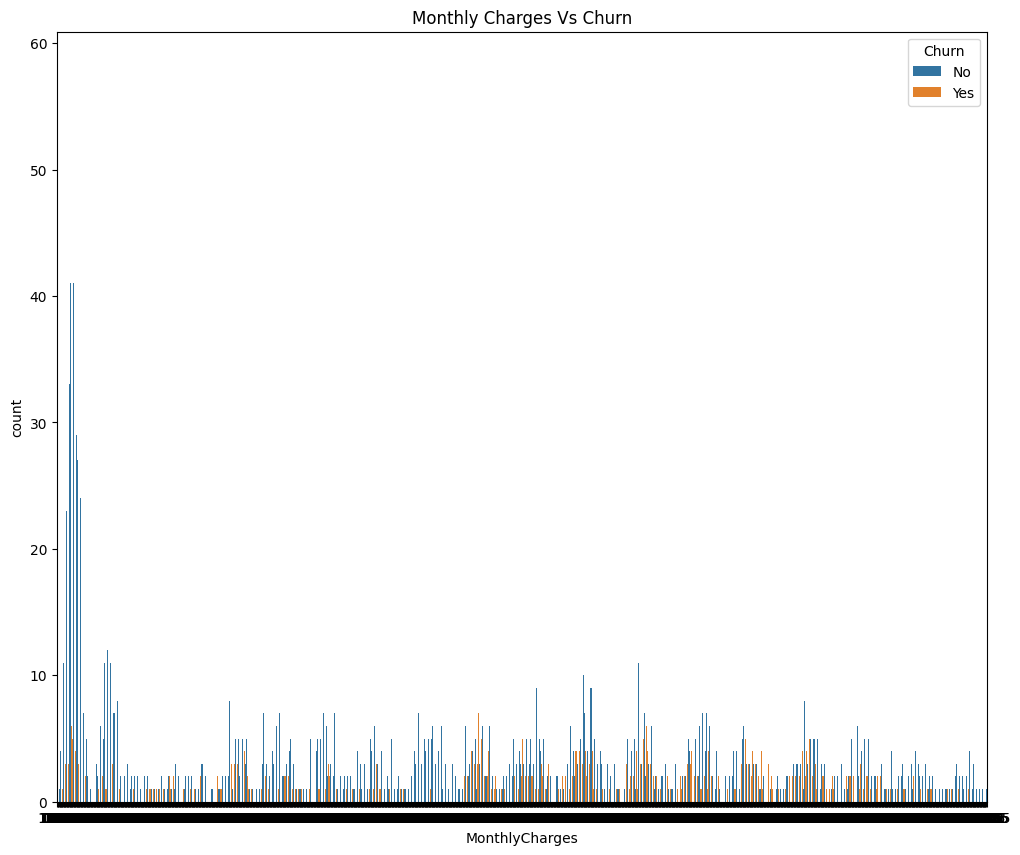

In [147]:
plt.figure(figsize=(12,10))
sns.countplot(x='MonthlyCharges',hue='Churn',data=nfive)
plt.title('Monthly Charges Vs Churn')
plt.show()

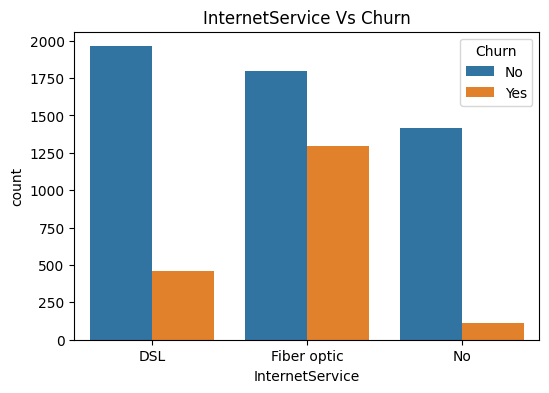

In [148]:
plt.figure(figsize=(6,4))
sns.countplot(x='InternetService',hue='Churn',data=nfive)
plt.title('InternetService Vs Churn')
plt.show()

In [149]:
pd.crosstab(nfive['InternetService'],nfive['Churn'],normalize='index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


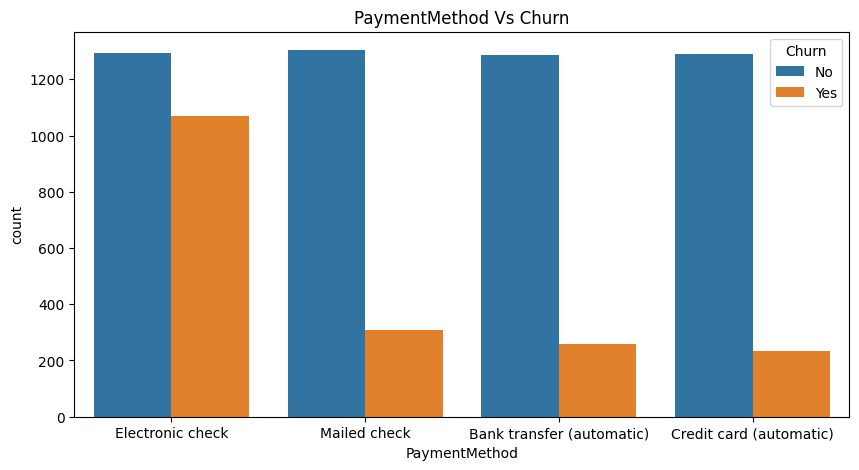

In [150]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod',hue='Churn',data=nfive)
plt.title('PaymentMethod Vs Churn')
plt.show()

In [151]:
pd.crosstab(nfive['PaymentMethod'],nfive['Churn'],normalize='index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


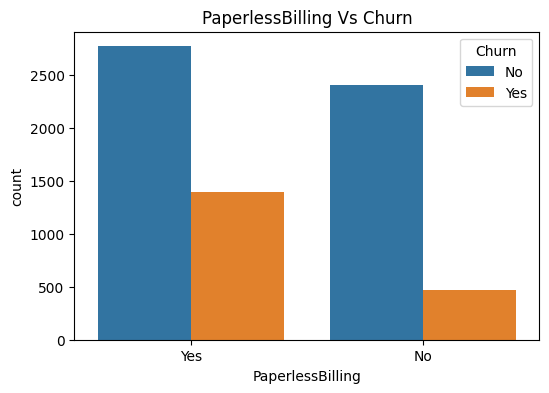

In [152]:
plt.figure(figsize=(6,4))
sns.countplot(x='PaperlessBilling',hue='Churn',data=nfive)
plt.title('PaperlessBilling Vs Churn')
plt.show()

In [153]:
pd.crosstab(nfive['PaperlessBilling'],nfive['Churn'],normalize='index')*100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


The exploratory data analysis revealed that customer churn is associated with several factors, including contract type, tenure, monthly charges, internet service, payment method, and paperless billing. Customers with month-to-month contracts, higher monthly charges, shorter tenure, and electronic check payments showed higher churn rates. The dataset contains no missing values or duplicate records; however, the target variable is moderately imbalanced (73% non-churn vs 27% churn).

Preprocessing


In [154]:
nfive.drop('customerID',axis=1,inplace=True)

In [155]:
nfive['TotalCharges']=pd.to_numeric(nfive['TotalCharges'],errors='coerce')
nfive['TotalCharges']=nfive['TotalCharges'].fillna(0)

In [156]:
nfive['TotalCharges'].dtype

dtype('float64')

In [157]:
nfive['TotalCharges'].isnull().sum()

np.int64(0)

Target Variable Encoding


In [158]:
nfive['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [159]:
nfive['Churn']=nfive['Churn'].map({'No':0,'Yes':1})


In [160]:
nfive['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [161]:
categorical_col=nfive.select_dtypes(include=['object']).columns
print(categorical_col)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [162]:
nfive=pd.get_dummies(nfive,drop_first=True)


In [163]:
nfive.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [164]:
nfive.shape

(7043, 31)

Seperate Feature and Target


In [165]:
X=nfive.drop('Churn',axis=1)
y=nfive['Churn']

In [166]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


In [167]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [168]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 30)
(1409, 30)
(5634,)
(1409,)


In [169]:
print('Churn' in X.columns)

False


In [170]:
X.columns.to_list()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

Feature Scaling


In [171]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numerical_cols = ['tenure','MonthlyCharges','TotalCharges']
X_train[numerical_cols]=scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols]=scaler.transform(X_test[numerical_cols])

In [172]:
X_train[numerical_cols].head()

,tenure,MonthlyCharges,TotalCharges
2142,-0.465683,-0.000474,-0.419925
1623,0.885537,1.074754,1.256017
6074,-1.284605,-1.376499,-1.000283
1362,-1.161766,0.177346,-0.905497
6754,-1.325551,-0.098524,-1.010646


Model one Linear Regression

In [173]:
from sklearn.linear_model import LogisticRegression
linear_reg=LogisticRegression(random_state=42,max_iter=1000)
linear_reg.fit(X_train,y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [174]:
from sklearn.tree import DecisionTreeClassifier
decision_tree=DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [175]:
decision_tree.predict(X_test)

array([1, 1, 0, ..., 0, 0, 1])

In [176]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [177]:
y_pred_linear_reg = linear_reg.predict(X_test)
print("Accuracy", accuracy_score(y_test, y_pred_linear_reg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear_reg))
print("Classification Report:\n", classification_report(y_test, y_pred_linear_reg))

Accuracy 0.8211497515968772
Confusion Matrix:
 [[934 102]
 [150 223]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [178]:
y_pred_decision_tree=decision_tree.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred_decision_tree))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_decision_tree))
print("Classification Report:\n",classification_report(y_test,y_pred_decision_tree))

Accuracy 0.7118523775727467
Confusion Matrix:
 [[832 204]
 [202 171]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80      1036
           1       0.46      0.46      0.46       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



Logistic Regression outperformed the Decision Tree across all evaluation metrics. It achieved a higher accuracy (82.11%), better precision (0.69), recall (0.60), and F1-score (0.64) for predicting customer churn. In comparison, the Decision Tree achieved only 71.19% accuracy with substantially lower precision and recall. Therefore, Logistic Regression is the preferred model for this dataset.

In [180]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':decision_tree.feature_importances_})
importance=importance.sort_values('Importance',ascending=False)
print(importance.head(3))

          Feature  Importance
2  MonthlyCharges    0.204417
1          tenure    0.199565
3    TotalCharges    0.197959


Based on the Decision Tree model, the three most influential features affecting customer churn are MonthlyCharges, tenure, and TotalCharges. Customers with higher monthly charges and shorter tenure are more likely to churn, while the total amount a customer has spent over time also plays a significant role in predicting churn.

Business Summary:
he customer churn analysis identified several important factors that influence whether a customer leaves the company. The Decision Tree model showed that MonthlyCharges, tenure, and TotalCharges are the three most important features affecting churn. After comparing both machine learning models, Logistic Regression achieved the best performance with an accuracy of 82.11%, outperforming the Decision Tree model (71.19%). The findings suggest that customers with higher monthly charges and shorter tenure are more likely to churn. These insights can help the company develop targeted retention strategies, such as offering loyalty rewards or personalized plans to customers who are at higher risk of leaving.

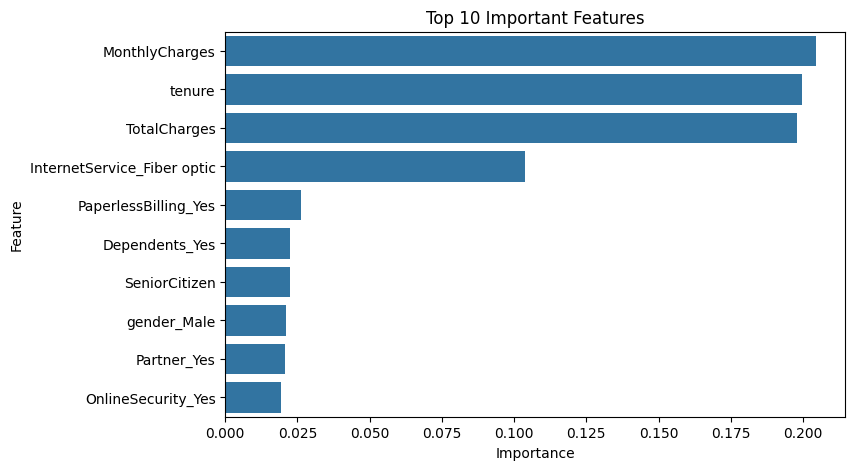

In [181]:
top_features = importance.head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_features,x="Importance",y="Feature")
plt.title("Top 10 Important Features")
plt.show()